The goal of this script is to create a function that takes in user inputted parameters for a cell (its width, length, and radius of holes) and outputs the band diagram for that strucutre. It is to note that this script will be made with the material being Silicon in a vacuum. 

In [4]:
# Importing Libraries: 

import meep as mp
import matplotlib.pyplot as plt
import numpy as np 
from IPython.display import Video 

%matplotlib inline 

Maxwell's Equations are scale invariant, because of this I will choose the characteristic length scale to be a micron

In [5]:
def unitcellbandstrucuture(width, length, diameter):
    # width - width of our beam in nanometers
    # length - length of our beam in nanometers
    # diameter - diameter of the holes in patterned into the beam in nanometers

    # Parameters for the computational cell: 
    pml_padding = length  
    padding_to_pml = 4*length
    sx = 1       #Respective sizes along given axis for our computational zone
    sy = 2*(pml_padding + padding_to_pml + width)/length  
    res = 100     # Pixels per micron -> 300 pixels per tenth of a micron to .3 pixels per nanometer

    cell = mp.Vector3(sx,sy)

    # For the silicon we want to use and our approximate target wavelength is below: 
    eps_silicon = 12
    thickness = 2.20
    wavelength = 15.40 

    # Defining our waveguide given the parameters, meep assumes periodic structure: 
    beam = mp.Block(size = (1e20, width/length, 1e20), material = mp.Medium(epsilon = eps_silicon) )
    holes = mp.Cylinder(radius = (diameter/2)/length, material = mp.Medium(epsilon = 1))

    geometry = [beam,holes]

    # Other things for simulation: It is to note that say we want to run for a certian number of periods, then we would divide our time by the frequency below
    fcenter = length/wavelength           # In meep units, the frequency is specified by 1/lambda according to https://meep.readthedocs.io/en/latest/Introduction/#units-in-meep
    df = .01*fcenter

    sym = mp.Mirror(direction=mp.Y, phase=-1)
    # Broad source to excite modes
    source = mp.Source(mp.GaussianSource(fcenter, fwidth = df), mp.Hz, mp.Vector3(0, 0))
    pml_layers = [mp.PML(pml_padding/length, direction =mp.Y)]

    simulation = mp.Simulation(
        cell_size = cell, 
        boundary_layers = pml_layers, 
        geometry = geometry, 
        sources = [source], 
        resolution = res, 
        symmetries=[sym]
    )

    f = plt.figure(dpi=200)
    simulation.plot2D(ax = f.gca())
    f.gca().xaxis.set_visible(False)
    f.suptitle('Geometry of Simulation')
    plt.show()


    h = mp.Harminv(mp.Hz, mp.Vector3(), fcenter, df)
  

    simulation.run(
    mp.at_beginning(mp.output_epsilon), 
    mp.after_sources(h),
    until_after_sources = 400
)
    
    simulation.sources = [
   mp.Source(mp.GaussianSource(fcenter, df), mp.Hz, mp.Vector3())
]   
    
    simulation.restart_fields()
    k_interp = 19
    kpts = mp.interpolate(k_interp, [mp.Vector3(0), mp.Vector3(.5)])
    all_freqs = simulation.run_k_points(300, kpts)

    kx = [k.x for k in kpts]
    fig = plt.figure(dpi=100, figsize=(5, 5))
    ax = plt.subplot(111)
    for i in range(len(all_freqs)):
        for ii in range(len(all_freqs[i])):
            plt.scatter(kx[i], np.real(all_freqs[i][ii]), color="b")

    ax.fill_between(kx, kx, 1.0, interpolate=True, color="gray", alpha=0.3)
    plt.xlim(0, .5)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.xlabel("$k_x(2\pi)$")
    plt.ylabel("$\omega(2\pi c)$")
    plt.tight_layout()
    plt.show()
    

<>:80: SyntaxWarning: invalid escape sequence '\p'
<>:81: SyntaxWarning: invalid escape sequence '\o'
<>:80: SyntaxWarning: invalid escape sequence '\p'
<>:81: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_510461/3986920858.py:80: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("$k_x(2\pi)$")
/tmp/ipykernel_510461/3986920858.py:81: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("$\omega(2\pi c)$")


     block, center = (0,0,0)
          size (1e+20,0.833333,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.166667, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)


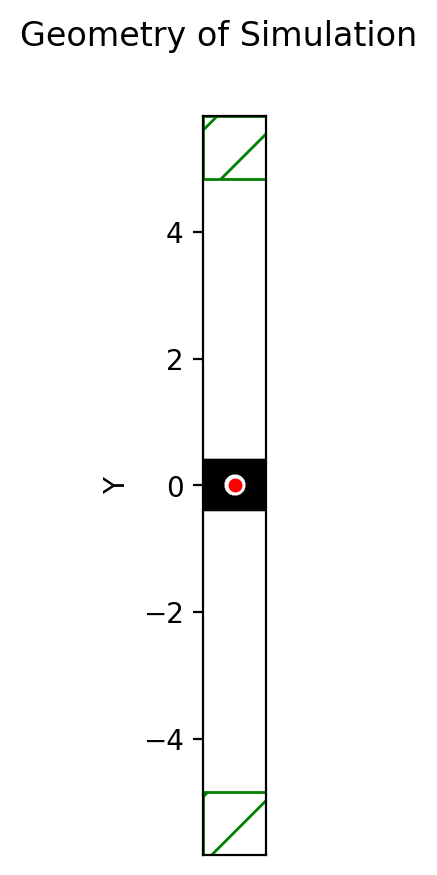

-----------
Initializing structure...
Padding y to even number of grid points.
Halving computational cell along direction y
time for choose_chunkdivision = 0.000572205 s
Working in 2D dimensions.
Computational cell is 1 x 11.67 x 0 with resolution 100
     block, center = (0,0,0)
          size (1e+20,0.833333,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.166667, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.066314 s
-----------
creating output file "./eps-000000000.h5"...
Meep progress: 72.79/2966.666748046875 = 2.5% done in 4.0s, 159.0s to go
on time step 14641 (time=73.205), 0.000273209 s/step
Meep progress: 144.69/2966.666748046875 = 4.9% done in 8.0s, 156.0s to go
on time step 29008 (time=145.04), 0.000278419 s/step
Meep progress: 214.57/2966.666748046875 = 7.2% done in 12.0s, 153.9s to go
on time step 430

KeyboardInterrupt: 

In [6]:
unitcellbandstrucuture(5.00,6.00,2.00)